In [1]:
!pip install timm==0.9.12

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import timm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import pandas as pd

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
    precision_recall_curve,
    precision_score, recall_score, f1_score
)
from sklearn.preprocessing import label_binarize

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 44.7 MB/s eta 0:00:00
  Attempting uninstall: timm
    Found existing installation: timm 1.0.26
    Uninstalling timm-1.0.26:
      Successfully uninstalled timm-1.0.26


In [2]:
DATA_PATH = "/content/drive/MyDrive/OID/Oral Images Dataset/augmented_data"

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

full_dataset = datasets.ImageFolder(DATA_PATH)

class_names = full_dataset.classes
num_classes = len(class_names)

targets = [label for _, label in full_dataset.samples]
class_counts = np.bincount(targets)

print("Classes:", class_names)
print("Class counts:", class_counts)

Classes: ['augmented_benign', 'augmented_malignant']
Class counts: [1155 1114]


In [10]:
from sklearn.model_selection import train_test_split

indices = np.arange(len(full_dataset))
labels = [label for _, label in full_dataset.samples]

train_idx, temp_idx = train_test_split(
    indices, test_size=0.3, stratify=labels, random_state=42
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=np.array(labels)[temp_idx],
    random_state=42
)

train_dataset = torch.utils.data.Subset(full_dataset, train_idx)
val_dataset   = torch.utils.data.Subset(full_dataset, val_idx)
test_dataset  = torch.utils.data.Subset(full_dataset, test_idx)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

In [11]:
class EfficientNetBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        base = torchvision.models.efficientnet_b0(pretrained=True)
        self.features = base.features

    def forward(self,x):
        x = self.features[0](x)
        x = self.features[1](x)
        F1 = self.features[2](x)
        F2 = self.features[3](F1)
        F3 = self.features[4:](F2)
        return F1,F2,F3


class ViTBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.vit = timm.create_model('vit_small_patch16_224', pretrained=True, num_classes=0)

    def forward(self,x):
        tokens = self.vit.forward_features(x)
        return tokens[:,0]


class FeatureFusionAttention(nn.Module):
    def __init__(self, cnn_dim, vit_dim, num_classes):
        super().__init__()

        fused_dim = cnn_dim + vit_dim

        self.cnn_aux = nn.Linear(cnn_dim, num_classes)
        self.vit_aux = nn.Linear(vit_dim, num_classes)

        self.proj = nn.Linear(fused_dim, 512)

        self.attn_dense = nn.Linear(512, 128)
        self.attn_score = nn.Linear(128, 512)

    def forward(self, h_cnn, h_vit):

        cnn_logits = self.cnn_aux(h_cnn)
        vit_logits = self.vit_aux(h_vit)

        fused = torch.cat([h_cnn, h_vit], dim=1)
        fused = F.relu(self.proj(fused))

        attn = F.relu(self.attn_dense(fused))
        attn = self.attn_score(attn)
        attn = F.softmax(attn, dim=1)

        fused = fused * attn
        return fused, cnn_logits, vit_logits


class OrCanNet(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.cnn = EfficientNetBackbone()
        self.vit = ViTBranch()
        self.fusion = FeatureFusionAttention(1280,384,num_classes)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(512,num_classes)

    def forward(self,x):
        _,_,F3 = self.cnn(x)
        h_cnn = torch.flatten(F.adaptive_avg_pool2d(F3,1),1)
        h_vit = self.vit(x)

        fused,cnn_logits,vit_logits = self.fusion(h_cnn,h_vit)

        fused = self.dropout(fused)
        out = self.classifier(fused)

        return out,cnn_logits,vit_logits

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = OrCanNet(num_classes).to(device)

weights = torch.tensor(1.0 / class_counts, dtype=torch.float).to(device)
lambda_aux = 0.1

def compute_loss(out,cnn_logits,vit_logits,labels):
    main = F.cross_entropy(out,labels,weight=weights,label_smoothing=0.1)
    aux1 = F.cross_entropy(cnn_logits,labels,weight=weights)
    aux2 = F.cross_entropy(vit_logits,labels,weight=weights)
    return main + lambda_aux*(aux1 + aux2)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [13]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

epochs = 30

train_losses, val_losses = [], []
train_accs, val_accs = [], []
epoch_times = []

start_training_time = time.time()

for epoch in range(epochs):

    epoch_start = time.time()

    model.train()
    train_loss, correct, total = 0,0,0

    all_train_preds, all_train_labels = [], []

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        out,cnn_logits,vit_logits = model(images)
        loss = compute_loss(out,cnn_logits,vit_logits,labels)

        loss.backward()
        optimizer.step()

        preds = torch.argmax(out,1)

        train_loss += loss.item()
        correct += (preds==labels).sum().item()
        total += labels.size(0)

        all_train_preds.extend(preds.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

    train_loss /= len(train_loader)
    train_acc = correct / total
    train_f1 = f1_score(all_train_labels, all_train_preds, average='macro')

    # VALIDATION
    model.eval()
    val_loss, correct, total = 0,0,0

    all_val_preds, all_val_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            out,cnn_logits,vit_logits = model(images)
            loss = compute_loss(out,cnn_logits,vit_logits,labels)

            preds = torch.argmax(out,1)

            val_loss += loss.item()
            correct += (preds==labels).sum().item()
            total += labels.size(0)

            all_val_preds.extend(preds.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)
    val_acc = correct / total
    val_f1 = f1_score(all_val_labels, all_val_preds, average='macro')

    epoch_time = time.time() - epoch_start
    epoch_times.append(epoch_time)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    print(f"Epoch Time: {epoch_time:.2f}s")

total_training_time = time.time() - start_training_time
print("Total Training Time:", total_training_time)

Epoch 1
Train Acc: 0.6952 | Val Acc: 0.9176
Epoch Time: 28.45s
Epoch 2
Train Acc: 0.8155 | Val Acc: 0.9765
Epoch Time: 29.51s
Epoch 3
Train Acc: 0.8652 | Val Acc: 0.9676
Epoch Time: 30.07s
Epoch 4
Train Acc: 0.9490 | Val Acc: 0.9706
Epoch Time: 33.06s
Epoch 5
Train Acc: 0.9521 | Val Acc: 0.9794
Epoch Time: 31.54s
Epoch 6
Train Acc: 0.9503 | Val Acc: 0.9794
Epoch Time: 30.23s
Epoch 7
Train Acc: 0.9395 | Val Acc: 0.9706
Epoch Time: 30.16s
Epoch 8
Train Acc: 0.9572 | Val Acc: 0.9765
Epoch Time: 30.22s
Epoch 9
Train Acc: 0.9950 | Val Acc: 0.9794
Epoch Time: 30.06s
Epoch 10
Train Acc: 0.9956 | Val Acc: 0.9794
Epoch Time: 30.07s
Epoch 11
Train Acc: 0.9981 | Val Acc: 0.9824
Epoch Time: 30.15s
Epoch 12
Train Acc: 0.9956 | Val Acc: 0.9765
Epoch Time: 30.09s
Epoch 13
Train Acc: 0.9868 | Val Acc: 0.9765
Epoch Time: 30.07s
Epoch 14
Train Acc: 0.9893 | Val Acc: 0.9824
Epoch Time: 30.23s
Epoch 15
Train Acc: 0.9868 | Val Acc: 0.9824
Epoch Time: 30.45s
Epoch 16
Train Acc: 0.9943 | Val Acc: 0.9794
Epoc

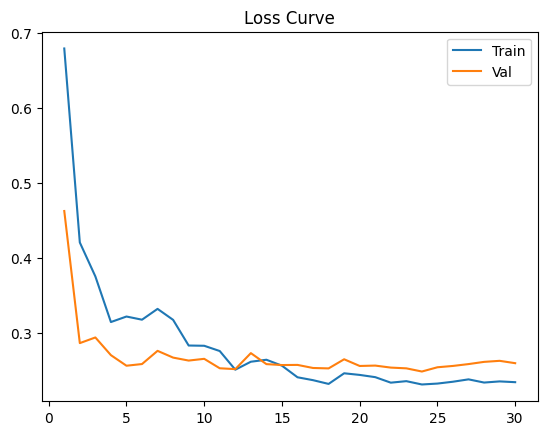

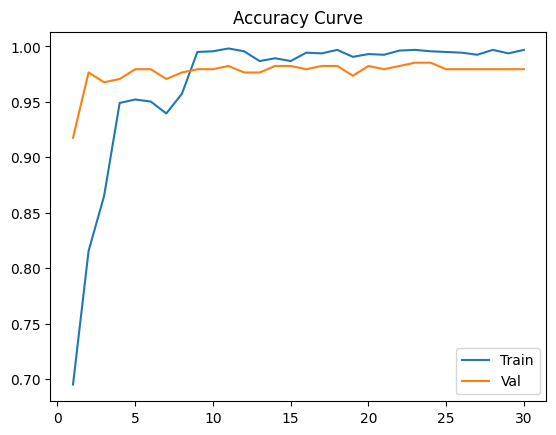

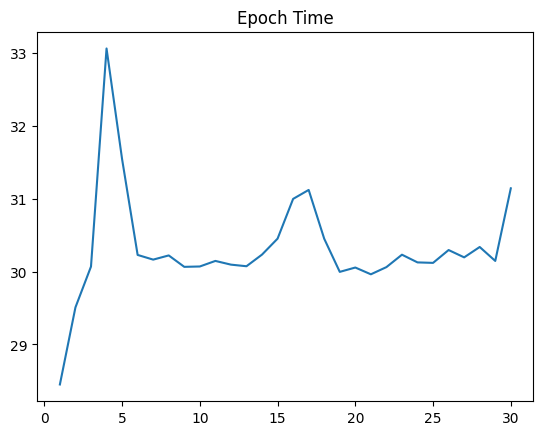

In [14]:
epochs_range = range(1, len(train_losses)+1)

plt.figure()
plt.plot(epochs_range, train_losses, label="Train")
plt.plot(epochs_range, val_losses, label="Val")
plt.title("Loss Curve")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs_range, train_accs, label="Train")
plt.plot(epochs_range, val_accs, label="Val")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs_range, epoch_times)
plt.title("Epoch Time")
plt.show()

In [15]:
model.eval()

all_preds, all_labels, all_probs = [], [], []

start_inf = time.time()
total_samples = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        out, _, _ = model(images)

        probs = torch.softmax(out, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

        total_samples += images.size(0)

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

inf_time = time.time() - start_inf
throughput = total_samples / inf_time

print("Inference Time:", inf_time)
print("Throughput:", throughput)

Inference Time: 2.9503283500671387
Throughput: 115.58035565507144


                     precision    recall  f1-score   support

   augmented_benign       0.99      0.99      0.99       174
augmented_malignant       0.99      0.99      0.99       167

           accuracy                           0.99       341
          macro avg       0.99      0.99      0.99       341
       weighted avg       0.99      0.99      0.99       341



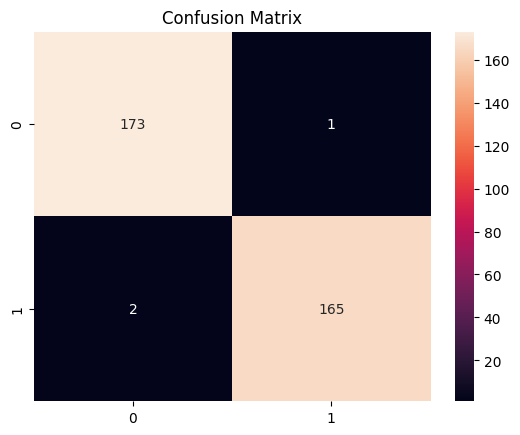

                     precision    recall  f1-score   support

   augmented_benign       0.99      0.99      0.99       174
augmented_malignant       0.99      0.99      0.99       167

           accuracy                           0.99       341
          macro avg       0.99      0.99      0.99       341
       weighted avg       0.99      0.99      0.99       341



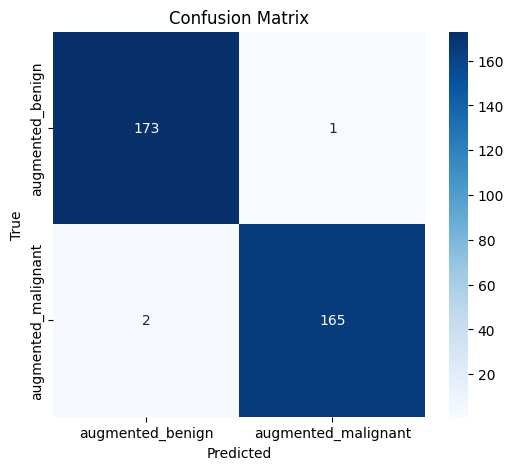

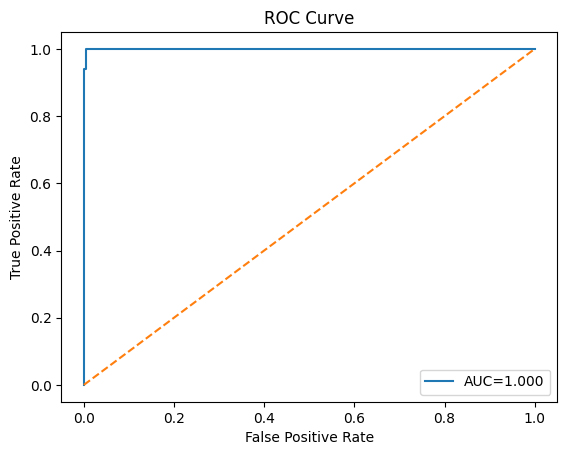

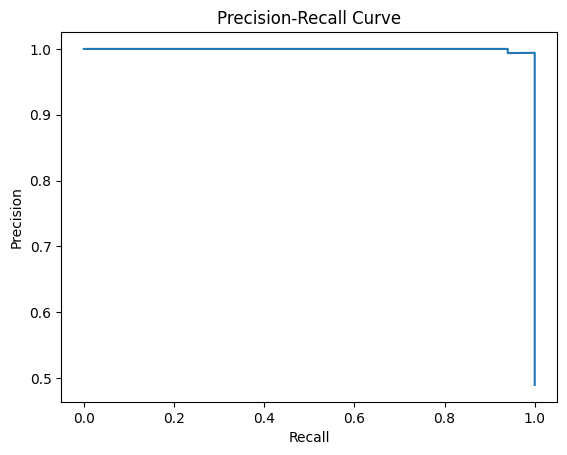

In [21]:
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

y_true_bin = label_binarize(all_labels, classes=[0,1])

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Binary ROC + PR
y_true_bin = label_binarize(all_labels, classes=[0,1]).ravel()

# ROC
fpr, tpr, _ = roc_curve(y_true_bin, all_probs[:,1])
auc = roc_auc_score(y_true_bin, all_probs[:,1])

plt.figure()
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# PR
precision, recall, _ = precision_recall_curve(y_true_bin, all_probs[:,1])

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [22]:
summary = pd.DataFrame({
    "Metric": [
        "Final Train Acc",
        "Final Val Acc",
        "ROC-AUC",
        "Training Time",
        "Inference Time",
        "Throughput"
    ],
    "Value": [
        train_accs[-1],
        val_accs[-1],
        auc,
        total_training_time,
        inf_time,
        throughput
    ]
})

print(summary)

            Metric       Value
0  Final Train Acc    0.996851
1    Final Val Acc    0.979412
2          ROC-AUC    0.999656
3    Training Time  909.614265
4   Inference Time    2.950328
5       Throughput  115.580356
